In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.simplefilter('ignore')

In [62]:
df = pd.read_csv('../../assets/rca-uber.csv', parse_dates=[4,5], dayfirst=True, na_values='NA')
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [44]:
print(f'Shape of the dataset: {df.shape}')
print('--------------------------------------------------------------')
print(f'null values count: \n{df.isnull().sum()/len(df)*100}')
print('--------------------------------------------------------------')
print(f'Duplicate rows count: {df.duplicated().sum()}')

Shape of the dataset: (6745, 6)
--------------------------------------------------------------
null values count: 
Request id            0.000000
Pickup point          0.000000
Driver id            39.288362
Status                0.000000
Request timestamp     0.000000
Drop timestamp       58.028169
dtype: float64
--------------------------------------------------------------
Duplicate rows count: 0


Extracting new features 

In [63]:
df['RequestTimeStamp_1'] = pd.to_datetime(df['Request timestamp'], format='%d-%m-%Y %H:%M:%S', errors='coerce')
df['RequestTimeStamp_2'] = pd.to_datetime(df['Request timestamp'], format='%d/%m/%Y %H:%M', errors='coerce')
df['Request timestamp'] = df['RequestTimeStamp_1'].combine_first(df['RequestTimeStamp_2'])

df['DropTimeStamp_1'] = pd.to_datetime(df['Drop timestamp'], format='%d-%m-%Y %H:%M:%S', errors='coerce')
df['DropTimeStamp_2'] = pd.to_datetime(df['Drop timestamp'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df['Drop timestamp'] = df['DropTimeStamp_1'].combine_first(df['DropTimeStamp_2'])
df.drop(columns=['RequestTimeStamp_1', 'RequestTimeStamp_2', 'DropTimeStamp_1', 'DropTimeStamp_2'], inplace=True)
df

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,NaT
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,NaT
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,NaT
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,NaT
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47
...,...,...,...,...,...,...
6740,6745,City,NaN,No Cars Available,2016-07-15 23:49:03,NaT
6741,6752,Airport,NaN,No Cars Available,2016-07-15 23:50:05,NaT
6742,6751,City,NaN,No Cars Available,2016-07-15 23:52:06,NaT
6743,6754,City,NaN,No Cars Available,2016-07-15 23:54:39,NaT


In [71]:
print(f'Request timestamp null values: {df["Request timestamp"].isnull().sum()}')
print(f'Drop timestamp null values: {df["Drop timestamp"].isnull().sum()}')

Request timestamp null values: 0
Drop timestamp null values: 5064


Extract hour from the Request timestamp

In [72]:
df['RequestHour'] = df['Request timestamp'].dt.hour

Timeslots of the day

In [73]:
df['TimeSlot'] = df['RequestHour'].apply(lambda x: 'Dawn' if x<=4 else ('Early Morning' if x<=9 else ('Noon' if x<=16 else ('Late Evening' if x<=21 else 'Night'))))
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Cab Availability,RequestHour,TimeSlot
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,NaT,Available,11,Noon
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,NaT,Available,17,Late Evening
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,NaT,Available,9,Early Morning
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,NaT,Available,21,Late Evening
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,Available,8,Early Morning


In [74]:
df['TimeSlot'].value_counts()

TimeSlot
Late Evening     2342
Early Morning    2103
Noon             1224
Dawn              578
Night             498
Name: count, dtype: int64

Distinguish the Supply-Demand Gap by a new variable Cab Availability where Supply is when Trip is Completed, all else is Demand

In [75]:
df['Cab Availability'] = df['Status'].apply(lambda x: 'Available' if x=='Trip Completed' else 'Not Available')
df

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Cab Availability,RequestHour,TimeSlot
0,619,Airport,1.0,Trip Completed,2016-07-11 11:51:00,NaT,Available,11,Noon
1,867,Airport,1.0,Trip Completed,2016-07-11 17:57:00,NaT,Available,17,Late Evening
2,1807,City,1.0,Trip Completed,2016-07-12 09:17:00,NaT,Available,9,Early Morning
3,2532,Airport,1.0,Trip Completed,2016-07-12 21:08:00,NaT,Available,21,Late Evening
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47,Available,8,Early Morning
...,...,...,...,...,...,...,...,...,...
6740,6745,City,NaN,No Cars Available,2016-07-15 23:49:03,NaT,Not Available,23,Night
6741,6752,Airport,NaN,No Cars Available,2016-07-15 23:50:05,NaT,Not Available,23,Night
6742,6751,City,NaN,No Cars Available,2016-07-15 23:52:06,NaT,Not Available,23,Night
6743,6754,City,NaN,No Cars Available,2016-07-15 23:54:39,NaT,Not Available,23,Night


In [76]:
df['Cab Availability'].value_counts(normalize=True)*100

Cab Availability
Not Available    58.028169
Available        41.971831
Name: proportion, dtype: float64

Q. What is the Frequency of Requests that get Canceled or show ‘No Cars Available’ in each hour?

Text(0.5, 1.0, 'Frequency of Requests by Hour and Status')

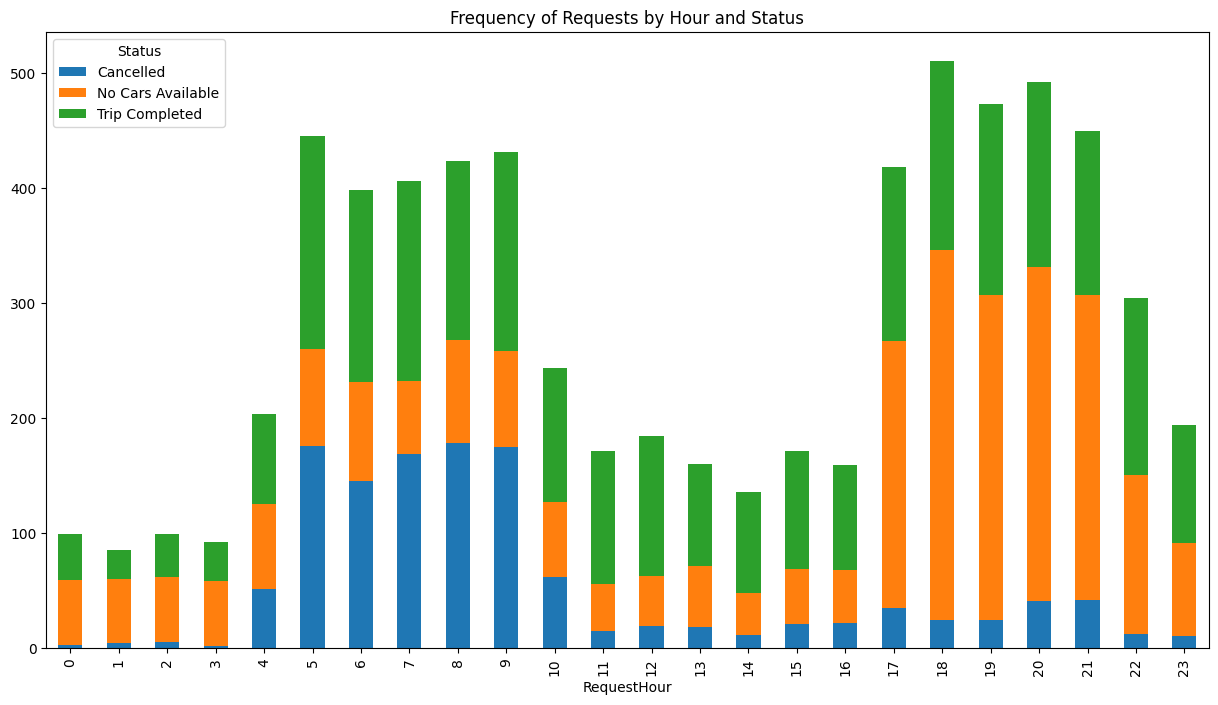

In [77]:
df.groupby(['RequestHour','Status']).size().unstack().plot(kind='bar', stacked=True, figsize=(15,8))
plt.title('Frequency of Requests by Hour and Status')

Types of Requests (city-airport or aiport-city)

Text(0.5, 1.0, 'Distribution of Requests')

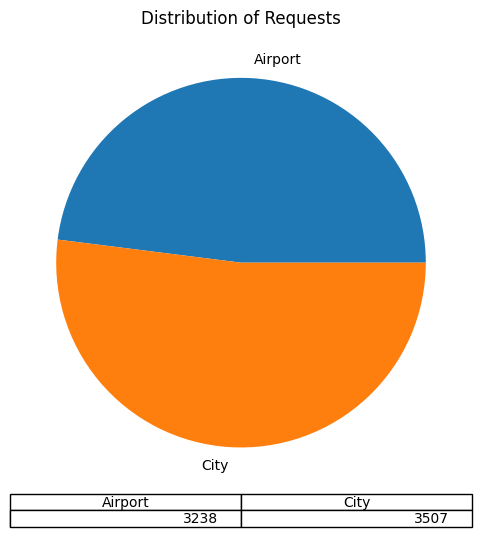

In [78]:
df.groupby(['Pickup point']).size().plot(kind='pie', stacked=True, figsize=(6,6), table=True)
plt.ylabel('')
plt.title('Distribution of Requests')

Distribution of Time slots

Text(0.5, 1.0, 'Distribution of Not Available Cabs by TimeSlot')

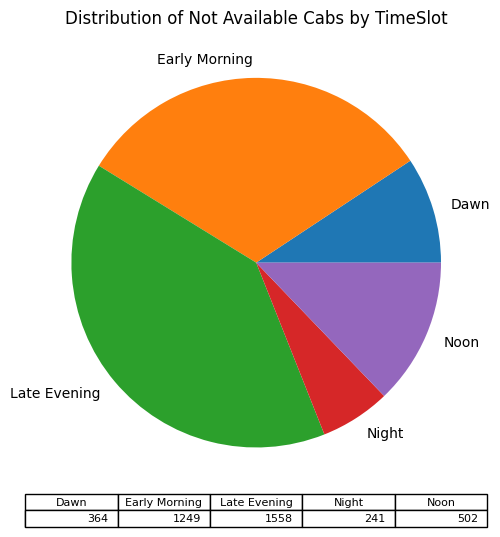

In [79]:
df[(df["Cab Availability"]=="Not Available")].groupby(['TimeSlot']).size().plot(kind="pie", stacked=True, figsize=(6, 6), table=True)
plt.ylabel("")
plt.title('Distribution of Not Available Cabs by TimeSlot')

Q. What are the Time Slots where the highest gap exists?

Text(0.5, 1.0, 'Time slots where highest gaps exist')

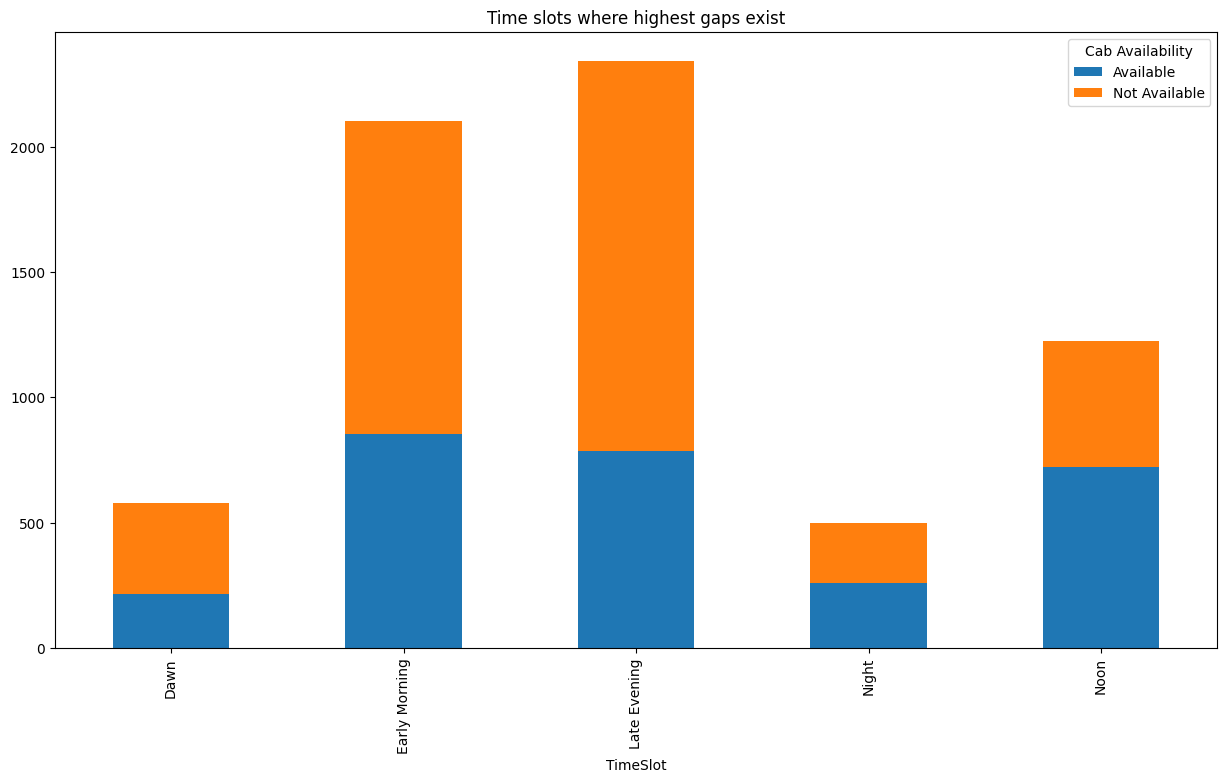

In [80]:
df.groupby(['TimeSlot','Cab Availability']).size().unstack().plot(kind='bar',stacked=True,figsize=(15,8))
plt.title('Time slots where highest gaps exist')

Observation:<br/>
Among the assumed time slots, we can see that the Late Evening and Early Morning time slots has got the highest gap.<br/>
This means that during evening & morning hours the probability of getting a cab is very less.

Types of Requests (city-airport or airport-city) for which the gap is the most severe in the identified time slots

<Axes: >

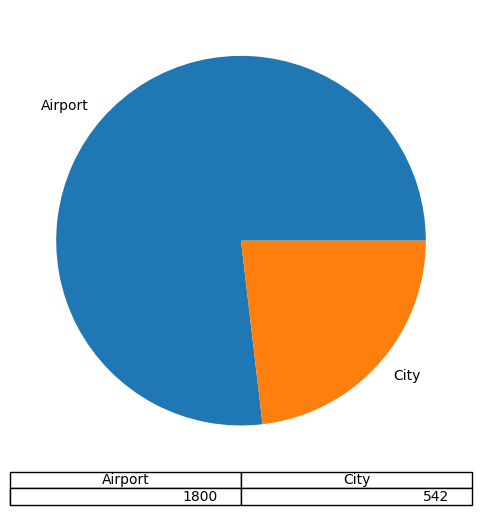

In [ ]:
df[df['TimeSlot']=='Late Evening'].groupby(['Pickup point']).size().plot(kind='pie',stacked=True,figsize=(6,6), table=True)

Types of Requests (city-airport or airport-city) for which the gap is the most severe in the identified time slots

Text(0, 0.5, '')

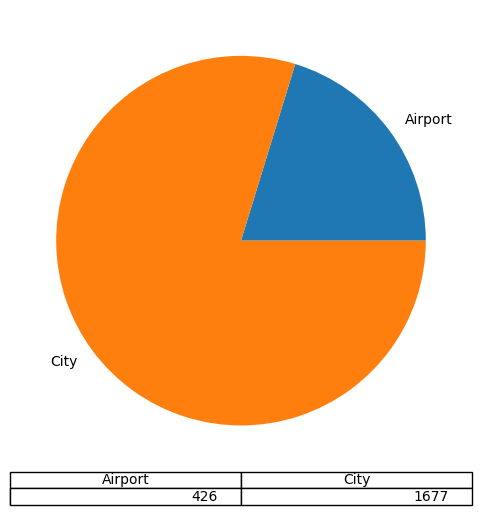

In [83]:
df[df["TimeSlot"]=="Early Morning"].groupby(['Pickup point']).size().plot(kind="pie",stacked=True,figsize=(6, 6), table=True)
plt.ylabel("")